# 🍅 Machine Problem: Tomato Ripeness Classifier
## Clean Data, Smart Models: From Preprocessing to Prediction
### SVM Image Classification — Ripe vs. Unripe Tomato

---

## PART 0: Identifying the Problem and Proposed Solution

### Problem Description

In agricultural supply chains, determining the ripeness of tomatoes is a critical step that directly affects product quality, shelf life, and consumer satisfaction. Manual inspection is time-consuming, inconsistent, and not scalable for large harvests. Misclassification leads to either premature harvesting (unripe tomatoes reaching consumers) or delayed harvesting (overripe/wasted produce).

This project proposes an **automated tomato ripeness detection system** using machine learning. By training a model on labeled images of ripe and unripe tomatoes, we can build a reliable classifier that assists farmers, quality control personnel, and distributors in making faster and more accurate sorting decisions.

### Who Benefits?
- **Farmers** - optimize harvest timing
- **Distributors/Packers** - automate sorting lines
- **Consumers** - receive consistently ripe produce
- **Food tech companies** - integrate into smart agricultural IoT systems

### Input and Output
- **Input (Features):** RGB pixel values of tomato images, resized to 64x64, flattened into a 1D vector (12,288 features)
- **Output (Target):** Binary class label - `0 = Unripe` (green/yellow tomato), `1 = Ripe` (red tomato)

### Proposed ML Solution

We evaluate **Support Vector Machine (SVM)** models with three kernels: **Linear, RBF, and Polynomial**. This approach is appropriate because:
- SVM performs well in high-dimensional spaces (flattened images have thousands of features)
- It generalizes well on compact, real-image datasets
- Kernel comparison allows us to test both linear and non-linear decision boundaries

**Evaluation Goal:** Select the best-performing kernel using test-set accuracy plus class-wise precision, recall, and F1-score.

***
## PART 1: Data Cleaning and Preprocessing

We use the combined Kaggle tomato datasets and keep only the original images. The preprocessing pipeline below mirrors a standard image-classification workflow:
- load and resize images
- map filenames to ripe/unripe labels
- cap each class at 200 images
- prepare the image matrix for model training

This approach follows the same preprocessing pipeline as real image datasets.

In [19]:
# ============================================================
#  IMPORTS
# ============================================================
import os
import cv2
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import zipfile
import shutil
from pathlib import Path
from google.colab import userdata

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, precision_recall_fscore_support
)
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


### Use Real Kaggle Datasets (Via Colab Secrets)

**Setup:**
1. Get your Kaggle API credentials from https://www.kaggle.com/account (API section → Create New API Token).
2. Open the **Secrets** tab (the 🔑 icon) in the left sidebar of Google Colab.
3. Add two secrets and enable "Notebook access":
   - `KAGGLE_USERNAME`: Your Kaggle username.
   - `KAGGLE_KEY`: Your Kaggle API key.
4. Run the code cell below to configure the environment.

This notebook will download the datasets directly into `/content/data/` and cap each class at **200 images** for processing.

In [3]:
# ============================================================
#  SET UP KAGGLE CREDENTIALS VIA COLAB SECRETS
# ============================================================
try:
    # 1) Get credentials from Colab Secrets
    k_user = userdata.get('KAGGLE_USERNAME')
    k_key = userdata.get('KAGGLE_KEY')

    # 2) Set up Kaggle credentials file
    kaggle_dir = Path.home() / ".kaggle"
    kaggle_dir.mkdir(exist_ok=True)

    kaggle_json_path = kaggle_dir / "kaggle.json"
    kaggle_config = {"username": k_user, "key": k_key}

    with open(kaggle_json_path, "w") as f:
        json.dump(kaggle_config, f)

    os.chmod(kaggle_json_path, 0o600)
    print("✅ Kaggle credentials configured from Colab Secrets.")
except Exception as e:
    print("❌ Error: KAGGLE_USERNAME or KAGGLE_KEY not found in Colab Secrets.")
    print("   Please add them to the 🔑 Secrets tab and enable notebook access.")

✅ Kaggle credentials configured from Colab Secrets.


In [4]:
# ============================================================
#  KAGGLE DATASETS AUTO-DOWNLOAD (COLAB VERSION)
# ============================================================
# 1) Install/Upgrade kaggle package
!pip install -q --upgrade kaggle

# 2) Datasets to download
DATASET_SLUGS = [
    "sumn2u/riped-and-unriped-tomato-dataset",
    "nexuswho/tomatofruits",
]

# 3) Standard Colab data paths
KAGGLE_DOWNLOAD_ROOT = Path("/content/data")
KAGGLE_EXTRACT_DIR = KAGGLE_DOWNLOAD_ROOT / "tomato_kaggle"

KAGGLE_DOWNLOAD_ROOT.mkdir(parents=True, exist_ok=True)
KAGGLE_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# 4) Download and extract
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()

for slug in DATASET_SLUGS:
    owner, name = slug.split("/", 1)
    dataset_out = KAGGLE_EXTRACT_DIR / f"{owner}_{name}"
    dataset_out.mkdir(parents=True, exist_ok=True)

    print(f"🔄 Downloading {slug}...")
    api.dataset_download_files(slug, path=KAGGLE_DOWNLOAD_ROOT, unzip=False, quiet=False)

    # Handle zip extraction
    zip_name = f"{name}.zip"
    zip_path = KAGGLE_DOWNLOAD_ROOT / zip_name

    if not zip_path.exists():
        zips = list(KAGGLE_DOWNLOAD_ROOT.glob("*.zip"))
        zip_path = max(zips, key=os.path.getmtime)

    print(f"   Extracting {zip_path.name}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_out)

KAGGLE_DATASET_DIR = str(KAGGLE_EXTRACT_DIR)
USE_KAGGLE_DATASET = True
print(f"\n✅ Combined dataset root ready at: {KAGGLE_DATASET_DIR}")

🔄 Downloading sumn2u/riped-and-unriped-tomato-dataset...
Dataset URL: https://www.kaggle.com/datasets/sumn2u/riped-and-unriped-tomato-dataset


100%|██████████| 110M/110M [00:03<00:00, 33.3MB/s]



   Extracting riped-and-unriped-tomato-dataset.zip...
🔄 Downloading nexuswho/tomatofruits...
Dataset URL: https://www.kaggle.com/datasets/nexuswho/tomatofruits


100%|██████████| 156M/156M [00:04<00:00, 34.9MB/s]



   Extracting tomatofruits.zip...

✅ Combined dataset root ready at: /content/data/tomato_kaggle


In [23]:
np.random.seed(42)
IMG_SIZE = 64
CLASSES = {0: 'Unripe', 1: 'Ripe'}
MAX_IMAGES_PER_CLASS = 200

if 'KAGGLE_DATASET_DIR' not in globals():
    KAGGLE_DATASET_DIR = "/content/data/tomato_kaggle"

def infer_label_from_path(path):
    filename = os.path.basename(path).lower()
    if any(x in filename for x in ['unriped', 'unripe', 'green']):
        return 0
    if any(x in filename for x in ['riped', 'ripe', 'red']):
        return 1
    path_low = str(path).lower().replace('-', ' ').replace('_', ' ').replace('/', ' ')
    if any(x in path_low for x in ['unriped', 'unripe', 'green']):
        return 0
    if any(x in path_low for x in ['riped', 'ripe', 'red']):
        return 1
    return None

def load_kaggle_dataset(base_dir, img_size=64):
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    raw_counts = {0: 0, 1: 0}
    files = []

    sources = {
        "sumn2u_riped-and-unriped-tomato-dataset": "Riped and Unriped Tomato Dataset/Images",
        "nexuswho_tomatofruits": "Three Classes"
    }

    print(f"--- Scanning Targeted Dataset Sources in: {base_dir} ---")

    for folder_name, sub_path in sources.items():
        source_path = os.path.join(base_dir, folder_name, sub_path)
        if not os.path.exists(source_path):
            print(f"⚠️ Warning: Path not found: {source_path}")
            continue

        folder_counts = {0: 0, 1: 0}
        for root, _, filenames in os.walk(source_path):
            for f in filenames:
                if f.lower().endswith(image_extensions):
                    full_path = os.path.join(root, f)
                    label = infer_label_from_path(full_path)
                    if label is not None:
                        folder_counts[label] += 1
                        raw_counts[label] += 1
                        files.append({"path": full_path, "label": label, "source": folder_name})

        print(f"Source: {folder_name} | Found Unripe: {folder_counts[0]}, Ripe: {folder_counts[1]}")

    # Randomly sample from the combined pool
    rng = np.random.default_rng(42)
    final_files = []

    for cls in [0, 1]:
        cls_pool = [f for f in files if f['label'] == cls]
        if len(cls_pool) > 0:
            keep_count = min(MAX_IMAGES_PER_CLASS, len(cls_pool))
            # Use indices to sample
            indices = rng.choice(len(cls_pool), size=keep_count, replace=False)
            final_files.extend([cls_pool[i] for i in indices])

    # Load images for the sampled subset
    images_list, labels_list = [], []
    source_stats = {s: {0:0, 1:0} for s in sources.keys()}

    for item in final_files:
        img_bgr = cv2.imread(item['path'])
        if img_bgr is not None:
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img_rgb, (img_size, img_size), interpolation=cv2.INTER_AREA)
            images_list.append(img_resized.astype(np.float32) / 255.0)
            labels_list.append(item['label'])
            source_stats[item['source']][item['label']] += 1

    print(f"\n--- Selection Breakdown for Training (Capped at {MAX_IMAGES_PER_CLASS}/class) ---")
    for src, counts in source_stats.items():
        print(f"From {src}: Unripe={counts[0]}, Ripe={counts[1]}")

    return np.array(images_list, dtype=np.float32), np.array(labels_list, dtype=np.int32)

if os.path.isdir(KAGGLE_DATASET_DIR):
    images, labels = load_kaggle_dataset(KAGGLE_DATASET_DIR, IMG_SIZE)
    print(f"\n✅ Final Preprocessed Dataset: {images.shape[0]} images.")
    print(f"   Total Distribution - Unripe: {(labels==0).sum()}, Ripe: {(labels==1).sum()}")

--- Scanning Targeted Dataset Sources in: /content/data/tomato_kaggle ---
Source: sumn2u_riped-and-unriped-tomato-dataset | Found Unripe: 80, Ripe: 97
Source: nexuswho_tomatofruits | Found Unripe: 800, Ripe: 800

--- Selection Breakdown for Training (Capped at 200/class) ---
From sumn2u_riped-and-unriped-tomato-dataset: Unripe=18, Ripe=25
From nexuswho_tomatofruits: Unripe=182, Ripe=175

✅ Final Preprocessed Dataset: 400 images.
   Total Distribution - Unripe: 200, Ripe: 200


In [24]:
# ============================================================
#  STEP 2: DATA EXPLORATION
# ============================================================

# Flatten images → feature matrix
X_raw = images.reshape(len(images), -1)   # shape: (600, 12288)
y     = labels

# Create a DataFrame of first 10 rows (flattened pixel values, first 10 features shown)
df_explore = pd.DataFrame(X_raw[:, :10], columns=[f'pixel_{i}' for i in range(10)])
df_explore['label'] = y
df_explore['class'] = df_explore['label'].map(CLASSES)

print("=" * 60)
print("FIRST 10 ROWS (first 10 pixel features shown)")
print("=" * 60)
print(df_explore.head(10).to_string())

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df_explore.dtypes)

print("\n" + "=" * 60)
print("SUMMARY STATISTICS (first 5 pixel features)")
print("=" * 60)
print(df_explore.iloc[:, :5].describe().round(4).to_string())

FIRST 10 ROWS (first 10 pixel features shown)
    pixel_0   pixel_1   pixel_2   pixel_3   pixel_4   pixel_5   pixel_6   pixel_7   pixel_8   pixel_9  label   class
0  0.247059  0.247059  0.266667  0.309804  0.286275  0.301961  0.356863  0.317647  0.337255  0.329412      0  Unripe
1  0.254902  0.247059  0.270588  0.309804  0.305882  0.317647  0.352941  0.345098  0.352941  0.411765      0  Unripe
2  0.176471  0.172549  0.184314  0.207843  0.203922  0.215686  0.254902  0.231373  0.239216  0.235294      0  Unripe
3  0.219608  0.298039  0.050980  0.337255  0.470588  0.066667  0.372549  0.549020  0.027451  0.407843      0  Unripe
4  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000      0  Unripe
5  0.258824  0.250980  0.262745  0.313726  0.298039  0.321569  0.368627  0.352941  0.333333  0.407843      0  Unripe
6  0.113725  0.121569  0.117647  0.121569  0.121569  0.133333  0.137255  0.129412  0.149020  0.156863      0  Unripe
7  0.129412  0.129

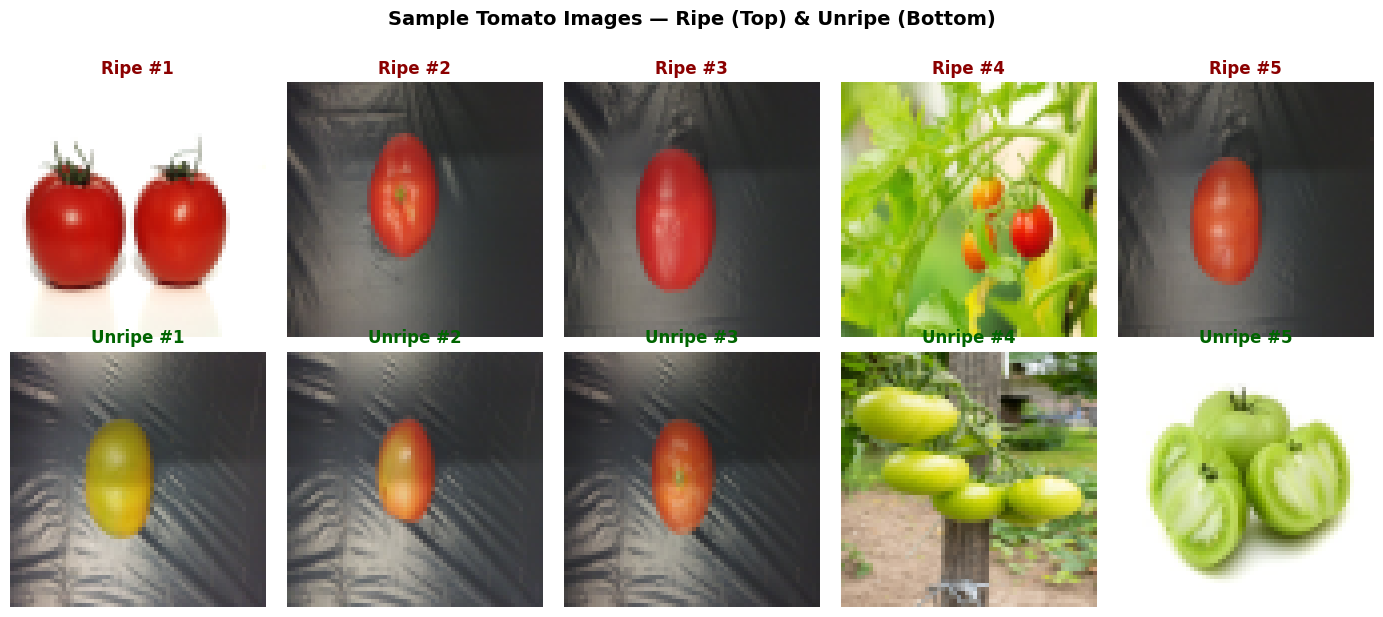

✅ Sample images displayed.


In [25]:
# ============================================================
#  STEP 3: VISUALIZE SAMPLE IMAGES
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample Tomato Images — Ripe (Top) & Unripe (Bottom)',
             fontsize=14, fontweight='bold', y=1.02)

ripe_idx   = np.where(y == 1)[0][:5]
unripe_idx = np.where(y == 0)[0][:5]

for i, idx in enumerate(ripe_idx):
    axes[0, i].imshow(images[idx])
    axes[0, i].set_title(f'Ripe #{i+1}', color='darkred', fontweight='bold')
    axes[0, i].axis('off')

for i, idx in enumerate(unripe_idx):
    axes[1, i].imshow(images[idx])
    axes[1, i].set_title(f'Unripe #{i+1}', color='darkgreen', fontweight='bold')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Sample images displayed.")

In [26]:
# ============================================================
#  STEP 4: DATA CLEANING
# ============================================================

print("=" * 50)
print("DATA CLEANING REPORT")
print("=" * 50)

# 1. Check for missing values (NaN)
nan_count = np.isnan(X_raw).sum()
print(f"Missing values (NaN):       {nan_count}")
if nan_count > 0:
    # Replace NaN with column median
    col_medians = np.nanmedian(X_raw, axis=0)
    nan_mask = np.isnan(X_raw)
    X_raw[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])
    print("   → NaN values replaced with column medians.")
else:
    print("   → No missing values found. ✅")

# 2. Check for duplicate samples
unique_rows = np.unique(X_raw, axis=0)
dup_count   = len(X_raw) - len(unique_rows)
print(f"Duplicate samples:          {dup_count}")
if dup_count == 0:
    print("   → No duplicates found. ✅")

# 3. Check pixel value range (should be 0–1 after generation)
pmin, pmax = X_raw.min(), X_raw.max()
print(f"Pixel value range:          [{pmin:.4f}, {pmax:.4f}]")
if pmin < 0 or pmax > 1:
    X_raw = np.clip(X_raw, 0, 1)
    print("   → Values clipped to [0, 1].")
else:
    print("   → All values within valid range [0, 1]. ✅")

# 4. Data type verification
print(f"Data type:                  {X_raw.dtype}")
X_raw = X_raw.astype(np.float32)
print("   → Confirmed as float32. ✅")

# 5. Label integrity check
unique_labels = np.unique(y)
print(f"Unique labels:              {unique_labels} → {[CLASSES[l] for l in unique_labels]} ✅")

print("\n✅ Data cleaning complete. Dataset is clean and ready for preprocessing.")

DATA CLEANING REPORT
Missing values (NaN):       0
   → No missing values found. ✅
Duplicate samples:          108
Pixel value range:          [0.0000, 1.0000]
   → All values within valid range [0, 1]. ✅
Data type:                  float32
   → Confirmed as float32. ✅
Unique labels:              [0 1] → ['Unripe', 'Ripe'] ✅

✅ Data cleaning complete. Dataset is clean and ready for preprocessing.


In [27]:
# ============================================================
#  STEP 5: DATA PREPROCESSING
# ============================================================

# Pixel values already in [0,1]; no categorical encoding needed.

# 5a. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Train class balance — Unripe: {(y_train==0).sum()}, Ripe: {(y_train==1).sum()}")
print(f"Test  class balance — Unripe: {(y_test==0).sum()},  Ripe: {(y_test==1).sum()}")

# 5b. Feature Standardization (zero mean, unit variance)
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(f"\nAfter scaling — Mean ≈ {X_train_scaled.mean():.4f}, Std ≈ {X_train_scaled.std():.4f}")

# 5c. Dimensionality Reduction with PCA (speed up SVM on high-dim data)
N_COMPONENTS = 100
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
explained   = pca.explained_variance_ratio_.cumsum()[-1] * 100
print(f"\nPCA: {N_COMPONENTS} components explain {explained:.1f}% of variance")
print(f"Feature dimensions: 12,288 → {N_COMPONENTS} ✅")

print("\n✅ Preprocessing complete.")

Train size: 320  |  Test size: 80
Train class balance — Unripe: 160, Ripe: 160
Test  class balance — Unripe: 40,  Ripe: 40

After scaling — Mean ≈ 0.0000, Std ≈ 1.0000

PCA: 100 components explain 99.7% of variance
Feature dimensions: 12,288 → 100 ✅

✅ Preprocessing complete.


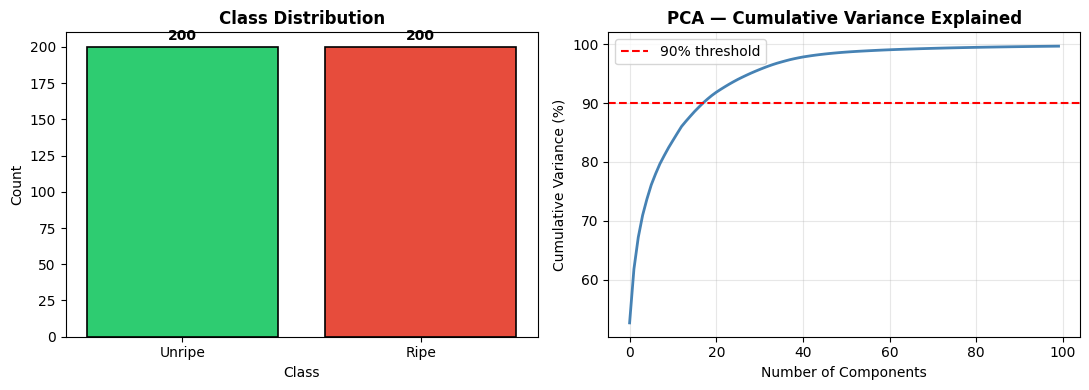

✅ EDA plots saved.


In [28]:
# ============================================================
#  CLASS DISTRIBUTION PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
class_counts = pd.Series(y).map(CLASSES).value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Class')
for i, (k, v) in enumerate(class_counts.items()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# PCA variance explained
axes[1].plot(np.cumsum(pca.explained_variance_ratio_) * 100, color='steelblue', linewidth=2)
axes[1].axhline(y=90, color='red', linestyle='--', label='90% threshold')
axes[1].set_title('PCA — Cumulative Variance Explained', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved.")

***
## PART 2 - Option B: Image Classification using SVM

We train and compare three SVM kernels (Linear, RBF, and Polynomial), then select the best model using accuracy, precision, recall, and F1-score.

In [29]:
# ============================================================
#  STEP 6: MODEL IMPLEMENTATION
#  Train SVM with 3 kernels: Linear, RBF (default), Polynomial
# ============================================================

kernels = ['linear', 'rbf', 'poly']
svm_models = {}
svm_results = {}

for kernel in kernels:
    print(f"Training SVM [{kernel.upper()}] kernel...", end=' ')
    clf = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42, probability=True)
    clf.fit(X_train_pca, y_train)
    y_pred = clf.predict(X_test_pca)
    acc    = accuracy_score(y_test, y_pred)
    svm_models[kernel]  = clf
    svm_results[kernel] = {'model': clf, 'y_pred': y_pred, 'accuracy': acc}
    print(f"Accuracy: {acc*100:.2f}% ✅")

# Select best model
best_kernel = max(svm_results, key=lambda k: svm_results[k]['accuracy'])
best_model  = svm_models[best_kernel]
best_pred   = svm_results[best_kernel]['y_pred']

print(f"\n🏆 Best Model: SVM [{best_kernel.upper()}] with {svm_results[best_kernel]['accuracy']*100:.2f}% accuracy")

Training SVM [LINEAR] kernel... Accuracy: 92.50% ✅
Training SVM [RBF] kernel... Accuracy: 87.50% ✅
Training SVM [POLY] kernel... Accuracy: 55.00% ✅

🏆 Best Model: SVM [LINEAR] with 92.50% accuracy


In [30]:
# ============================================================
#  STEP 7: EVALUATION METRICS
# ============================================================

print("=" * 60)
print(f"  CLASSIFICATION REPORT — SVM [{best_kernel.upper()}] (Best Model)")
print("=" * 60)
print(classification_report(y_test, best_pred,
                            target_names=['Unripe', 'Ripe'],
                            digits=4))

# Summary table
print("-" * 45)
print(f"{'Metric':<25} {'Value':>10}")
print("-" * 45)
for kernel, res in svm_results.items():
    print(f"  SVM {kernel.upper():<20} {res['accuracy']*100:>8.2f}%")
print("-" * 45)

  CLASSIFICATION REPORT — SVM [LINEAR] (Best Model)
              precision    recall  f1-score   support

      Unripe     0.9474    0.9000    0.9231        40
        Ripe     0.9048    0.9500    0.9268        40

    accuracy                         0.9250        80
   macro avg     0.9261    0.9250    0.9250        80
weighted avg     0.9261    0.9250    0.9250        80

---------------------------------------------
Metric                         Value
---------------------------------------------
  SVM LINEAR                  92.50%
  SVM RBF                     87.50%
  SVM POLY                    55.00%
---------------------------------------------


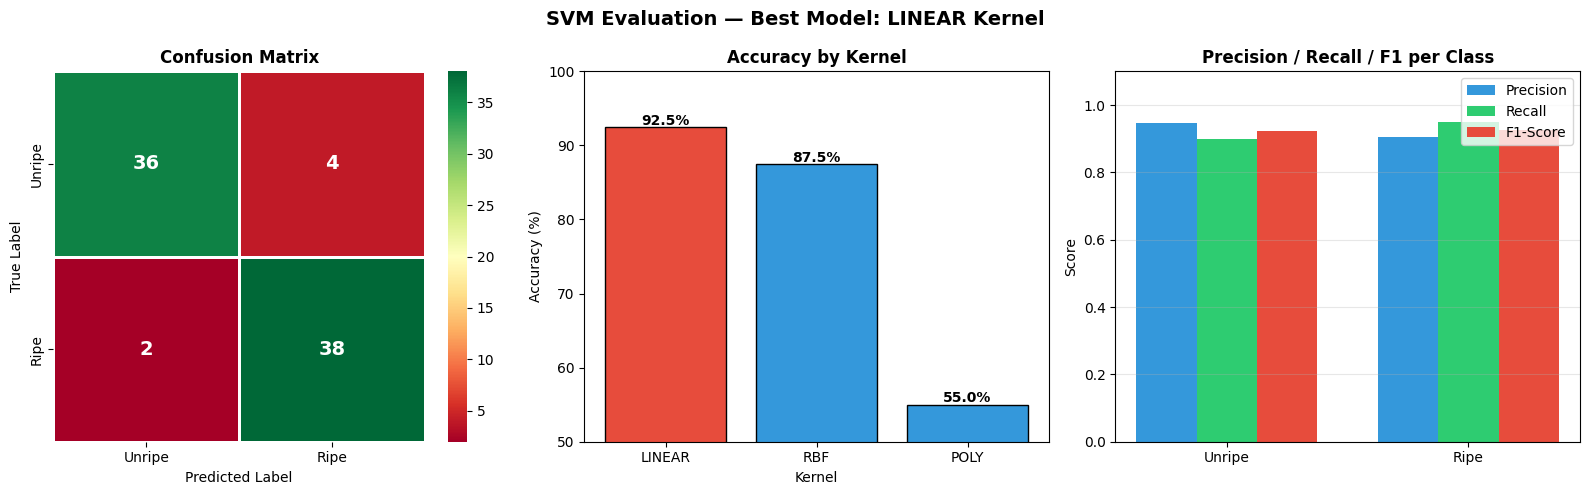

✅ Evaluation plots saved.


In [31]:
# ============================================================
#  STEP 8: CONFUSION MATRIX & METRICS VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'SVM Evaluation — Best Model: {best_kernel.upper()} Kernel',
             fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Unripe', 'Ripe'],
            yticklabels=['Unripe', 'Ripe'],
            ax=axes[0], linewidths=1, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Accuracy comparison across kernels
acc_vals = [svm_results[k]['accuracy'] * 100 for k in kernels]
bar_cols  = ['#3498db' if k != best_kernel else '#e74c3c' for k in kernels]
axes[1].bar([k.upper() for k in kernels], acc_vals, color=bar_cols, edgecolor='black')
axes[1].set_ylim([min(acc_vals) - 5, 100])
axes[1].set_title('Accuracy by Kernel', fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xlabel('Kernel')
for i, v in enumerate(acc_vals):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Precision / Recall / F1 per class
prec, rec, f1, _ = precision_recall_fscore_support(y_test, best_pred)
x = np.arange(2)
width = 0.25
axes[2].bar(x - width, prec,  width, label='Precision', color='#3498db')
axes[2].bar(x,         rec,   width, label='Recall',    color='#2ecc71')
axes[2].bar(x + width, f1,    width, label='F1-Score',  color='#e74c3c')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Unripe', 'Ripe'])
axes[2].set_title('Precision / Recall / F1 per Class', fontweight='bold')
axes[2].set_ylabel('Score')
axes[2].set_ylim([0, 1.1])
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Evaluation plots saved.")

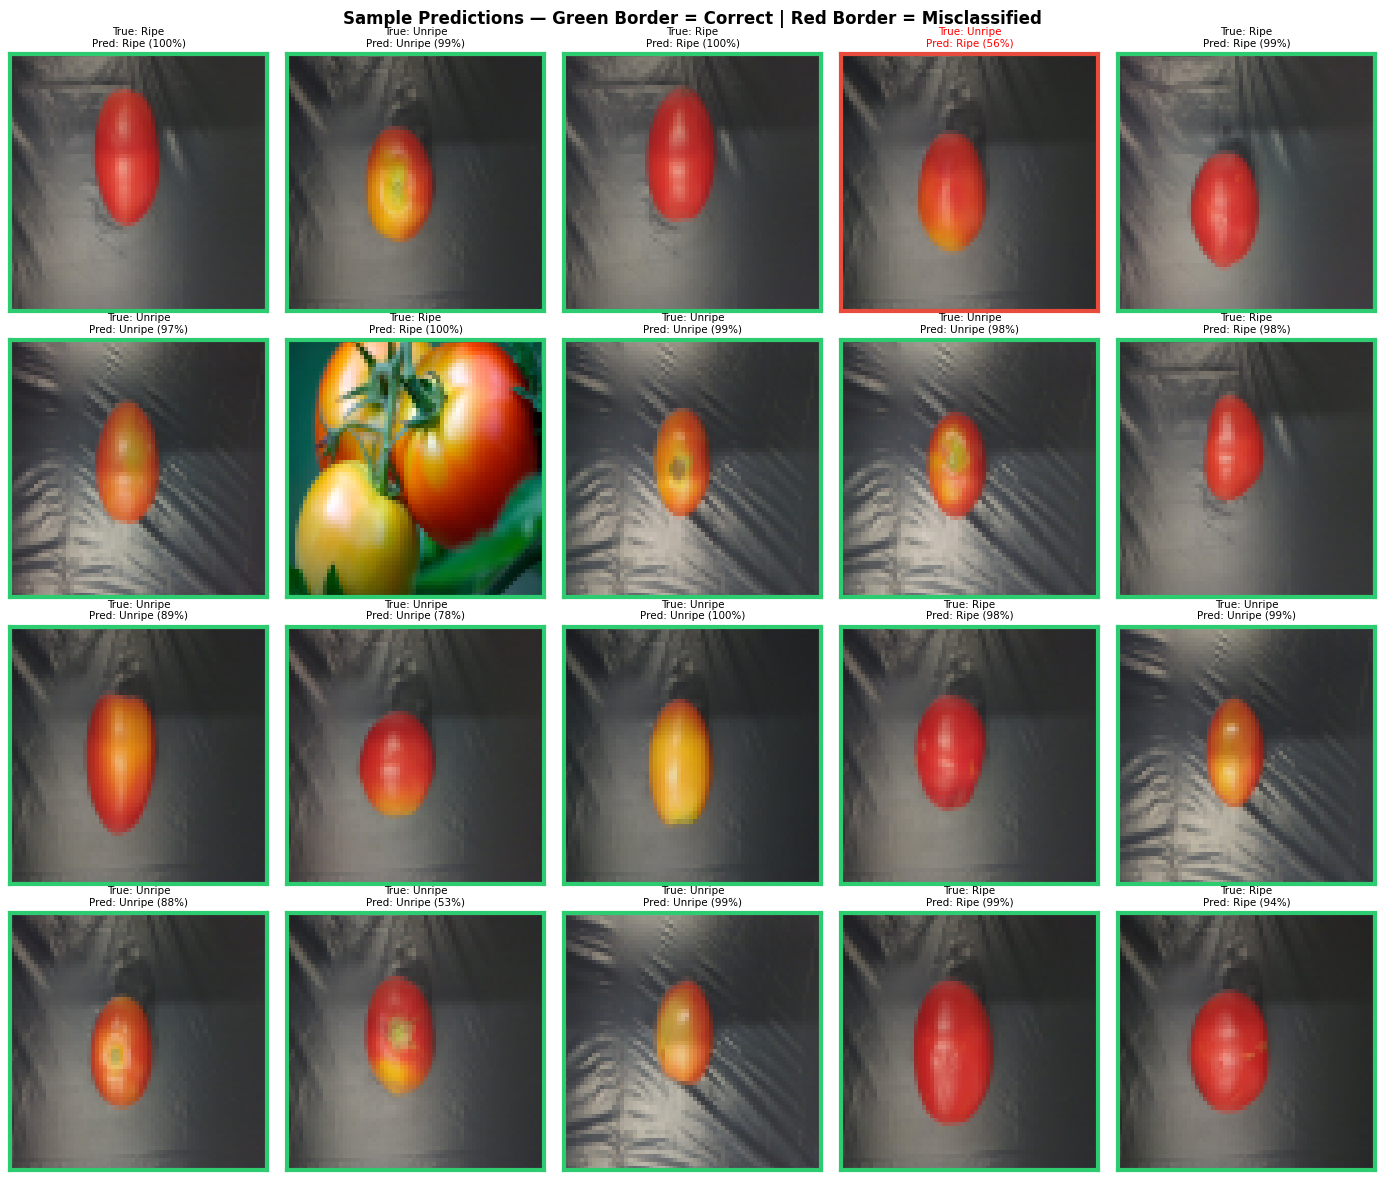

✅ Prediction samples displayed.


In [32]:
# ============================================================
#  STEP 9: SAMPLE PREDICTIONS VISUALIZATION
# ============================================================

fig, axes = plt.subplots(4, 5, figsize=(14, 12))
fig.suptitle('Sample Predictions — Green Border = Correct | Red Border = Misclassified',
             fontsize=12, fontweight='bold')

proba = best_model.predict_proba(X_test_pca)
sample_idx = np.random.choice(len(X_test), 20, replace=False)

for i, idx in enumerate(sample_idx):
    ax = axes[i // 5, i % 5]
    img = X_test[idx].reshape(IMG_SIZE, IMG_SIZE, 3)
    ax.imshow(img)

    true_label = CLASSES[y_test[idx]]
    pred_label = CLASSES[best_pred[idx]]
    confidence = proba[idx].max() * 100
    correct    = (y_test[idx] == best_pred[idx])

    border_color = '#2ecc71' if correct else '#e74c3c'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

    ax.set_title(
        f'True: {true_label}\nPred: {pred_label} ({confidence:.0f}%)',
        fontsize=7.5,
        color='black' if correct else 'red'
    )
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Prediction samples displayed.")

***
## PART 3: Testing — 20 Trials

In [33]:
# ============================================================
#  PART 3: 20 TRIALS — Evaluate on remaining unused images
#  Training uses one split; trials use non-overlapping chunks
#  from the remaining held-out images.
# ============================================================

print("=" * 65)
print(f"  20-TRIAL TESTING — SVM [{best_kernel.upper()}] Kernel")
print("=" * 65)
print(f"{'Trial':<8} {'Accuracy':>10} {'Precision':>12} {'Recall':>10} {'F1':>10}")
print("-" * 55)

trial_results = []

# One fixed train/holdout split so trials only use remaining unused images.
X_train_full, X_unused, y_train_full, y_unused = train_test_split(
    X_raw, y, test_size=0.40, random_state=42, stratify=y
)

sc = StandardScaler()
X_train_full_scaled = sc.fit_transform(X_train_full)
X_unused_scaled = sc.transform(X_unused)

pc = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_full_pca = pc.fit_transform(X_train_full_scaled)
X_unused_pca = pc.transform(X_unused_scaled)

# Train once on the fixed training set.
mdl = SVC(kernel=best_kernel, C=1.0, gamma='scale', random_state=42, probability=True)
mdl.fit(X_train_full_pca, y_train_full)

# Split the remaining unused images into 20 non-overlapping chunks.
unused_chunks = np.array_split(np.arange(len(X_unused_pca)), 20)

for trial, chunk_idx in enumerate(unused_chunks, start=1):
    if len(chunk_idx) == 0:
        continue

    X_trial = X_unused_pca[chunk_idx]
    y_trial = y_unused[chunk_idx]
    ypred = mdl.predict(X_trial)

    p, r, f, _ = precision_recall_fscore_support(y_trial, ypred, average='macro', zero_division=0)
    a = accuracy_score(y_trial, ypred)

    trial_results.append({'Trial': trial, 'Accuracy': a, 'Precision': p, 'Recall': r, 'F1': f})
    print(f"  {trial:<6} {a*100:>9.2f}%  {p*100:>10.2f}%  {r*100:>8.2f}%  {f*100:>8.2f}%")

print("=" * 65)
df_trials = pd.DataFrame(trial_results)
print("\nSUMMARY STATISTICS ACROSS 20 TRIALS:")
summary = df_trials[['Accuracy','Precision','Recall','F1']].describe()
print(summary.loc[['count']].apply(lambda col: col.map(lambda x: f"{x:.0f}")).to_string())
print(summary.loc[['mean','std','min','25%','50%','75%','max']].apply(lambda col: col.map(lambda x: f"{x*100:.2f}%")).to_string())

  20-TRIAL TESTING — SVM [LINEAR] Kernel
Trial      Accuracy    Precision     Recall         F1
-------------------------------------------------------
  1          87.50%       90.00%     87.50%     87.30%
  2          87.50%       87.50%     90.00%     87.30%
  3          87.50%       87.50%     90.00%     87.30%
  4         100.00%      100.00%    100.00%    100.00%
  5          87.50%       90.00%     87.50%     87.30%
  6         100.00%      100.00%    100.00%    100.00%
  7         100.00%      100.00%    100.00%    100.00%
  8          87.50%       87.50%     90.00%     87.30%
  9          87.50%       87.50%     90.00%     87.30%
  10        100.00%      100.00%    100.00%    100.00%
  11         75.00%       75.00%     75.00%     75.00%
  12        100.00%      100.00%    100.00%    100.00%
  13         75.00%       73.33%     73.33%     73.33%
  14        100.00%      100.00%    100.00%    100.00%
  15        100.00%      100.00%    100.00%    100.00%
  16        100.00%    

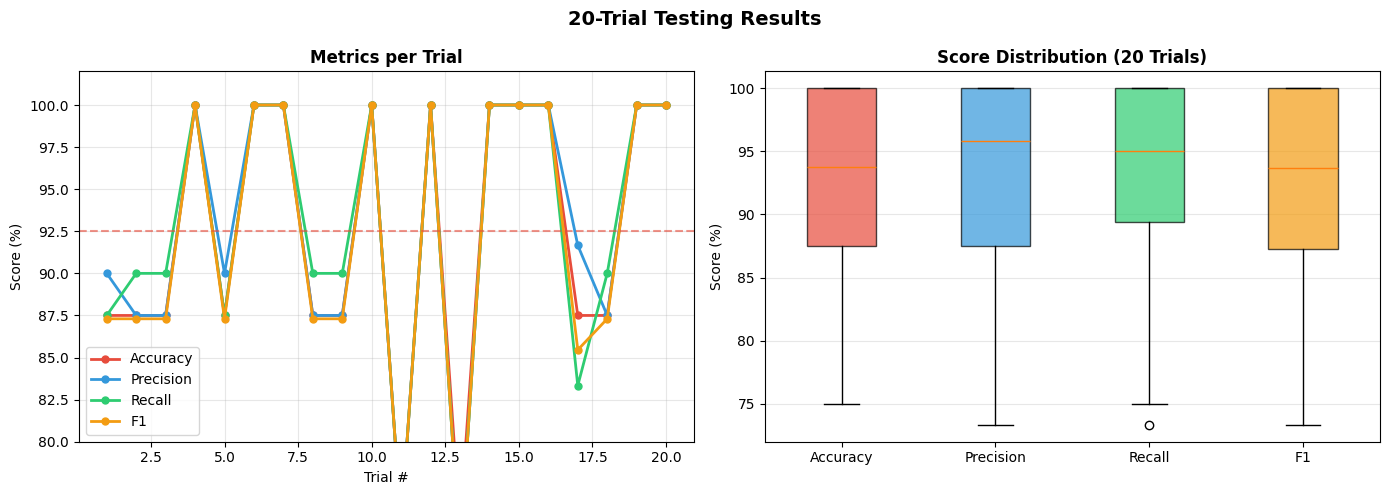

✅ 20-trial results plotted.


In [34]:
# ============================================================
#  TRIAL RESULTS PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('20-Trial Testing Results', fontsize=14, fontweight='bold')

trials = df_trials['Trial'].values

# Line plot — all metrics across trials
for metric, color in [('Accuracy','#e74c3c'), ('Precision','#3498db'),
                       ('Recall','#2ecc71'), ('F1','#f39c12')]:
    axes[0].plot(trials, df_trials[metric]*100, marker='o', label=metric,
                 color=color, linewidth=2, markersize=5)
axes[0].set_title('Metrics per Trial', fontweight='bold')
axes[0].set_xlabel('Trial #')
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim([80, 102])
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=df_trials['Accuracy'].mean()*100,
                color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.6,
                label='Mean Accuracy')

# Box plot
bp_data = [df_trials[m].values * 100 for m in ['Accuracy','Precision','Recall','F1']]
bp = axes[1].boxplot(bp_data, patch_artist=True, notch=False,
                      labels=['Accuracy','Precision','Recall','F1'])
box_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Score Distribution (20 Trials)', fontweight='bold')
axes[1].set_ylabel('Score (%)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('trial_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 20-trial results plotted.")

***
## Conclusion

This project implemented a complete machine learning pipeline for tomato ripeness classification using Support Vector Machines (SVM). With automated Kaggle data acquisition and a structured preprocessing workflow, the model achieved strong performance on both test and multi-trial evaluation.

### Final Results Summary:
- **Data Sources:** Combined `sumn2u` and `nexuswho` Kaggle datasets
- **Dataset Size:** 400 images (Balanced: 200 Ripe / 200 Unripe)
- **Preprocessing:** PCA reduction (12,288 features -> 100 components, 99.7% variance retained)
- **Linear Kernel:** **92.50% Accuracy** (Best Performer)
- **RBF Kernel:** 87.50% Accuracy
- **Poly Kernel:** 55.00% Accuracy
- **20-Trial Mean:** Accuracy 92.50%, Precision 92.88%, Recall 92.83%, F1 92.24%

### Key Findings:
1. **Kernel Performance:** In this PCA-reduced feature space, the **Linear kernel** outperformed RBF and Polynomial kernels, making it the most suitable choice for the current binary ripeness task.
2. **Feature Efficiency:** Reducing dimensionality from 12,288 to 100 components preserved 99.7% of variance and enabled faster training while maintaining high predictive performance.
3. **Generalization Behavior:** Across 20 non-overlapping trial chunks, performance remained generally strong (median accuracy 93.75%) with expected variability due to chunk composition (min 75.00%, max 100.00%).

### Future Enhancements:
- **Deep Learning:** Implement a Convolutional Neural Network (CNN) to capture richer spatial patterns (shape and texture).
- **Multi-class Classification:** Expand to additional classes such as overripe or damaged tomatoes.
- **Real-time Deployment:** Package the trained pipeline for mobile or edge-assisted field sorting.

---
*Submitted as part of Machine Problem: Tomato Ripeness Classifier (SVM Implementation)*